# » `Dependencias`:

In [ ]:
# !pip install plotly
# !pip install sqlalchemy
# !pip install numpy
# !pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [5]:
def get_query_sql(query):
  try:
    df = pd.read_sql(query, connection)
    return df
  except:
    print('¡Ocurrió un error!')

## 3. Visualización de datos: `INF-OCT2024`

### 3.1 1. Se define como regla que, todos los vuelos registrados en el A.I.J.C.H., deben tener un itinerario asociado y registrado en el sistema.

In [19]:
# Extracción
df_1 = pd.read_excel('./data/A1.xlsx')

<Axes: >

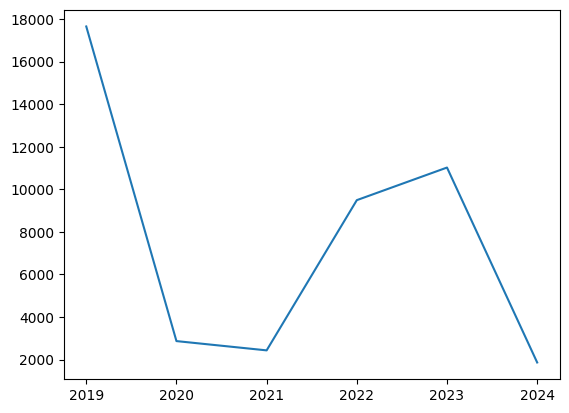

In [21]:
# Campos: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Pais Origen/Destino', 'Id Itinerario', 'Via Transporte']

df_1['dAñoControlControl'] = df_1['Fecha Control'].dt.year

df_1_1 = df_1.groupby(by=['dAñoControlControl']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1)

df_1_1.plot(legend=False, xlabel='')

### 3.2 Se define como regla que, los puestos de control fronterizo no deben registrar transporte aéreo o marítimo como medio de transporte en el proceso de control migratorio.

In [22]:
df_2 = pd.read_excel('./data/A2.xlsx')

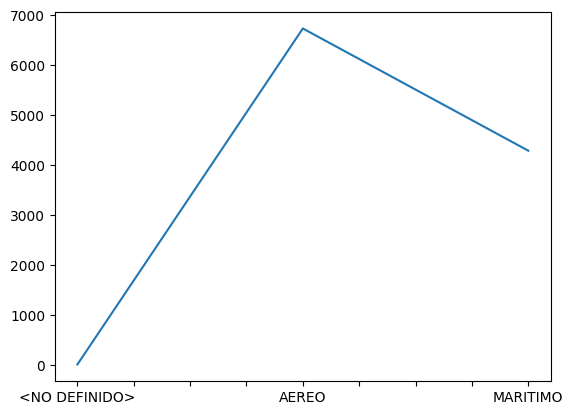

In [24]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Via Transporte']

df_2_f = df_2.groupby(by=['Via Transporte']).agg({ 'Id Mov Migratorio': [np.ma.count] }).droplevel(level=0, axis=1)
df_2_f = df_2_f.plot(legend=False, xlabel='')


### 3.3 Se define como regla que, los registros de control migratorio deben registrar explícitamente una dependencia.

In [26]:
df_3 = pd.read_excel('./data/A3.xlsx')

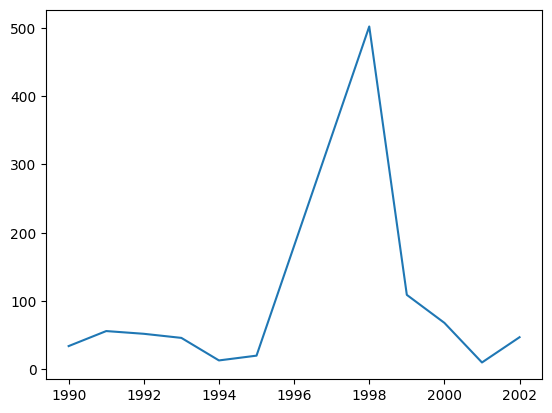

In [28]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia']

df_3['Año Control'] = df_3['Fecha Control'].dt.year

df_3_f = df_3.groupby(by=['Año Control']).agg({ 'Id Mov Migratorio': [np.ma.count] }).droplevel(level=0, axis=1).head(11)
df_3_f = df_3_f.plot(legend=False, xlabel='')

### 3.4 Se define como regla que, la dependencia de Lima no debe tener registros de Control Migratorio.

In [6]:
df_4 = pd.read_excel('./data/A4.xlsx')

<Axes: >

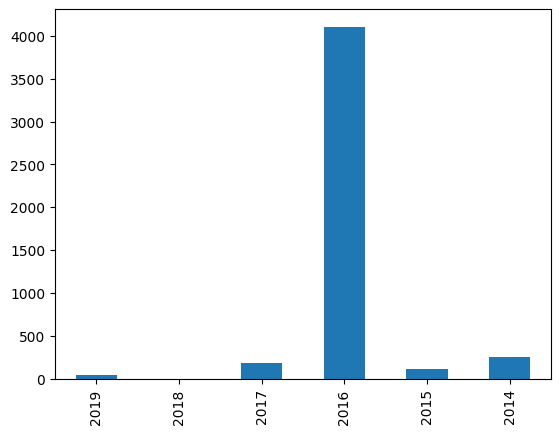

In [14]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Id Itinerario', 'Fecha Programada', 'Número Nave', 'Cantidad Pasajeros', 'Aerolinea']
# ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Via Transporte']

df_4['Año Control'] = df_4['Fecha Control'].dt.year

df_4_1 = df_4.groupby(by=['Año Control']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='Año Control', ascending=False) \
             .head(6)

df_4_1.plot.bar(legend=False, xlabel='')


### 3.5 Se define como regla que, las dependencias de Puesto de Control Fronterizo, deben excluir el transporte aéreo de sus registros de movimientos.

In [16]:
df_5 = pd.read_excel('./data/A5.xlsx')

<Axes: >

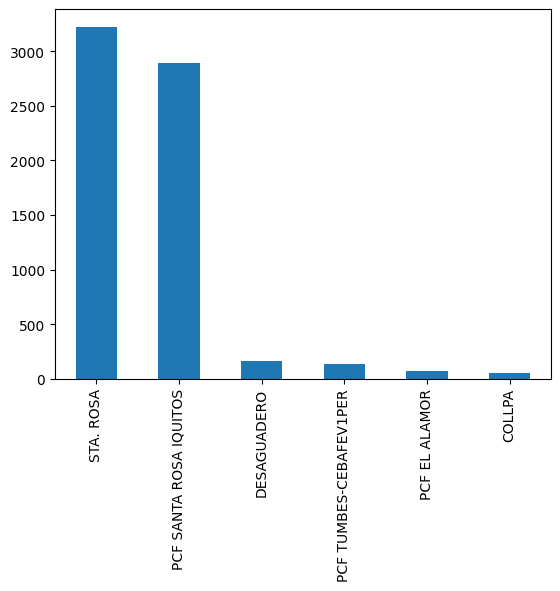

In [21]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Via Transporte', 'Año Control']


df_5['Año Control'] = df_5['Fecha Control'].dt.year

df_5_1 = df_5.groupby(by=['Dependencia']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(6)

df_5_1.plot.bar(legend=False, xlabel='')
